In [ ]:
]activate ../../../
code
#VSC-1725083b
julia
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")
code
#VSC-d0025776
julia
using CairoMakie
using GLMakie
CairoMakie.activate!()
markdown
#VSC-2ee9cdae
markdown
# Testing v1
code
#VSC-9a8151b3
julia
f = jldopen("./data4.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

N = fmetadata.N
M = fmetadata.M
sN = fmetadata.sN
dx = fmetadata.L / sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

Klips
markdown
#VSC-fafe5526
markdown
## Make run reports
code
#VSC-6d8de34e
julia
make_v1_report(f, "./rep4/")
markdown
#VSC-75b7e729
markdown
# Total biomass
code
#VSC-abbd18cf
julia
f
cell_type
id
metadata
source

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [26]:
df = DataFrame(;
    Ks = vcat([fill(Klips[i][1], fmetadata.num_runs) for i in 1:length(Klips)]...),
    lis = vcat([fill(Klips[i][2], fmetadata.num_runs) for i in 1:length(Klips)]...),
    ps = vcat([fill(Klips[i][3], fmetadata.num_runs) for i in 1:length(Klips)]...),
    params=f["params"][:],
    fss=f["sp_final_states"][:],
    fTs=f["sp_final_Ts"][:],
    rcs=f["sp_retcodes"][:],
    ode_fss=f["ode_final_states"][:],
    ode_fTs=f["ode_final_Ts"][:],
    ode_rcs=f["ode_retcodes"][:],
    ls_mrls=f["linstab_mrls"][:],
);

In [78]:
df.fs_means = map(df.fss) do fs
    mean(fs; dims=2)[:]
end
df.fs_smeans = getindex.(df.fs_means, Ref(1:fmetadata.N));
df.fs_totbiom = sum.(df.fs_smeans);
df.ode_smeans = getindex.(df.ode_fss, Ref(1:fmetadata.N))
df.ode_totbiom = sum.(df.ode_smeans);

In [79]:
sdf = @subset df :rcs .== ReturnCode.Success .&& :fTs .== fmetadata.T;
nrow(sdf), nrow(df)

(450, 500)

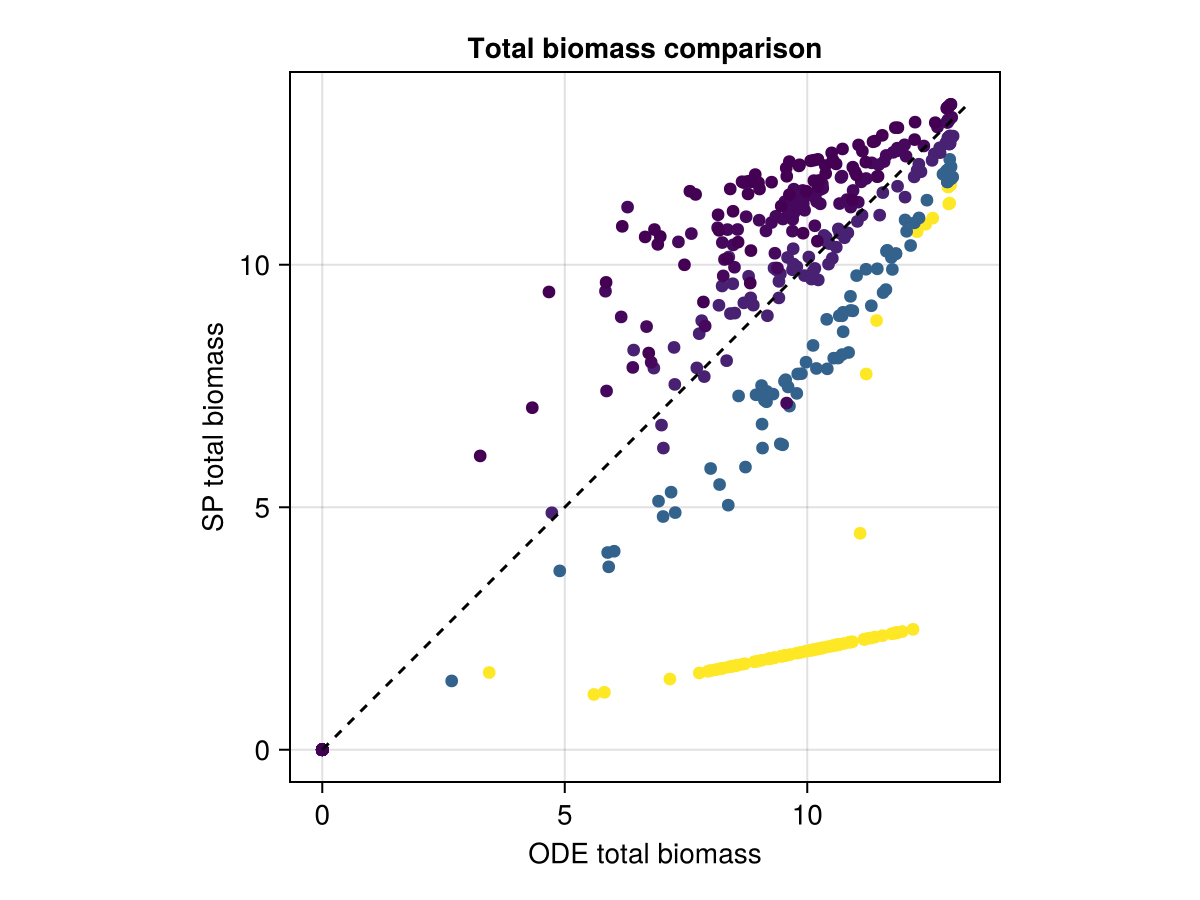

In [80]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel="ODE total biomass",
    ylabel="SP total biomass",
    title="Total biomass comparison",
    aspect=AxisAspect(1.),
)
scatter!(ax, sdf.ode_totbiom, sdf.fs_totbiom;
    color=sdf.ps,
)

mm = max(maximum(sdf.ode_totbiom), maximum(sdf.fs_totbiom))
lines!(ax, [0., mm], [0., mm]; color=:black, linestyle=:dash)

fig

In [81]:
pgroups = groupby(sdf, :ps);

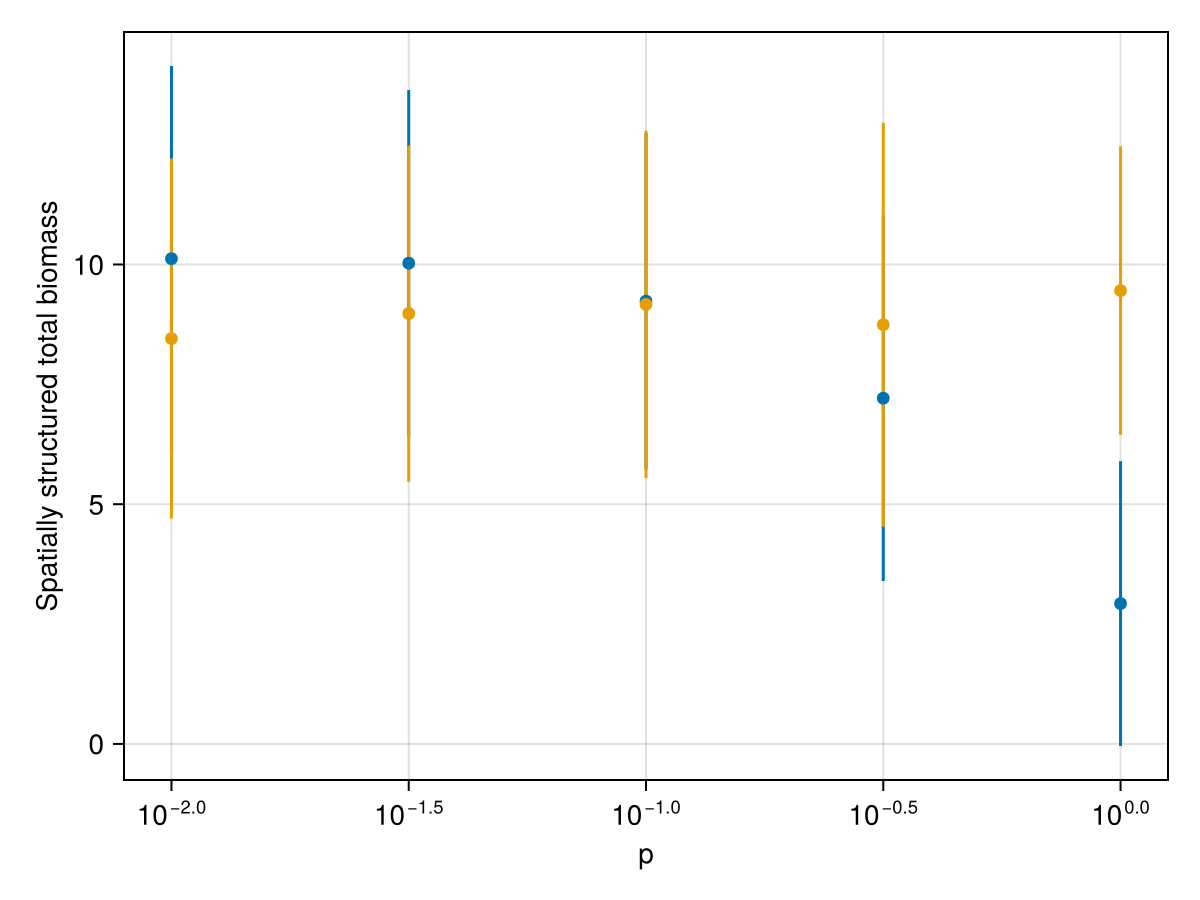

In [ ]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel="p",
    ylabel="Spatially structured total biomass",
)

for pg in pgroups
    p = pg.ps[1]
    ode_tbs = pg.ode_totbiom
    sp_tbs = pg.fs_totbiom
    sp_mean = mean(sp_tbs)
    ode_mean = mean(ode_tbs)
    sp_err = std(sp_tbs)
    ode_err = std(ode_tbs)

    errorbars!(ax, [p], [sp_mean], [sp_err];
        color=Cycled(1),
    )
    errorbars!(ax, [p], [ode_mean], [ode_err];
        color=Cycled(2),
    )
    scatter!(ax, [p], [sp_mean];
        color=Cycled(1),
    )
    scatter!(ax, [p], [ode_mean];
        color=Cycled(2),
    )
end

fig

In [ ]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel="p",
    ylabel="Total biomass",
    title="Total biomass distributions by p",
)

for pg in pgroups
    p = pg.ps[1]
    ode_tbs = pg.ode_totbiom
    sp_tbs = pg.fs_totbiom

    violin!(ax, fill(p, length(sp_tbs)), sp_tbs;
        color=RGBAf(0.2745, 0.5098, 0.7059, 0.35),
        side=:left,
    )
    violin!(ax, fill(p, length(ode_tbs)), ode_tbs;
        color=RGBAf(1.0, 0.549, 0.0, 0.35),
        side=:right,
    )
end

fig

LoadError: Failed to resolve [31marg1:[39m
[ComputeEdge] [31marg1[39m = compute_identity(([31mmeshes[39m, ), changed, cached)
[90m  @ /home/honza/.julia/packages/ComputePipeline/03tW7/src/ComputePipeline.jl:737[39m
[ComputeEdge] [31mmeshes[39m = (::MapFunctionWrapper(poly_convert))(([92mpolygon[39m, [92mtransform_func[39m, ), changed, cached)
[90m  @ unknown method location[39m
  with edge inputs:
    polygon = Vector{Point{2, Float32}}[[[0.31622776, 17.507864], [0.3161676, 17.507864], [0.3161694, 17.393076], [0.31616426, 17.27829], [0.31615162, 17.163502], [0.31613043, 17.048716], [0.31609887, 16.933928], [0.31605437, 16.819141], [0.3159934, 16.704353], [0.31591132, 16.589567]  …  [0.315564, -4.416479], [0.31572974, -4.5312667], [0.31585646, -4.646054], [0.3159524, -4.760841], [0.31602418, -4.875628], [0.31607708, -4.990415], [0.3161152, -5.105202], [0.31614164, -5.2199893], [0.31615862, -5.3347764], [0.31622776, -5.3347764]]]
    transform_func = (log10, identity)
Tri